**Goal:** watch a single decision tree score a perfect 1.000 on training data and then
stumble on new frogs -- the high-variance overfitting L09 warned about -- then cure it by
growing a whole forest and letting the trees vote. You will fit and read a tree, use
`max_depth` as a dial, bag many trees into an ensemble, and read a random forest's feature
importances. Pairs with the concept note
[Decision Trees & Bagging](l12_concept_trees_bagging.qmd).

> **Previously:** L11 -- Evaluation Metrics (closed Unit III)  |  **Next:** L13 -- Boosting

> This page is the read-only view. To run the lab, open the notebook
> (`l12_lab_trees_bagging.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

A field team has recorded 600 coqui calls and measured eight acoustic features per call,
hoping to tell two species apart automatically. Five of the features carry signal -- four
genuinely informative (`call_pitch`, `call_rate`, `chirp_len`, `trill_depth`) plus
`amp_var`, a redundant linear combination of them -- while three (`noise1`, `noise2`,
`noise3`) are pure noise the microphone happened to log. The classes are roughly balanced,
so -- unlike the L11 disease screen -- plain accuracy is an honest score here.

The data is **synthetic** (a fixed seed, identical for everyone) with *fictionalized but
plausible* values -- the framing is real, the numbers are not field measurements.

## Setup

The setup is **two cells** (the pattern every lab uses). The first only installs; the
second imports, seeds the generator, builds the data, and splits it.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships scikit-learn, numpy, pandas and matplotlib, so this is effectively a no-op there.
%pip install -q scikit-learn
# local, in a terminal (not in the notebook):  uv add scikit-learn numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEED, DATA (safe to re-run without re-installing)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

feature_names = ["call_pitch", "call_rate", "chirp_len", "trill_depth", "amp_var",
                 "noise1", "noise2", "noise3"]
# shuffle=False keeps the columns in order so the names line up: 4 informative + 1 redundant = 5 signal, then 3 pure noise.
X, y = make_classification(n_samples=600, n_features=8, n_informative=4, n_redundant=1,
                           n_classes=2, class_sep=0.9, flip_y=0.05,
                           shuffle=False, random_state=11)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,
                                                    random_state=11, stratify=y)
print(len(X_train), "train /", len(X_test), "test")

420 train / 180 test


~~~text
420 train / 180 test
~~~

## Step 1: One Tree Overfits

Grow a single decision tree with no depth limit -- it splits until its leaves are pure --
and compare its training and test accuracy:

In [3]:
tree_full = DecisionTreeClassifier(random_state=11).fit(X_train, y_train)

print(f"tree depth: {tree_full.get_depth()}")
print(f"train accuracy: {accuracy_score(y_train, tree_full.predict(X_train)):.3f}")
print(f"test accuracy:  {accuracy_score(y_test, tree_full.predict(X_test)):.3f}")

tree depth: 10
train accuracy: 1.000
test accuracy:  0.717


~~~text
tree depth: 10
train accuracy: 1.000
test accuracy:  0.717
~~~

A perfect **1.000** on training data and **0.717** on the test set. The tree grew ten
levels deep and memorized the training sample -- noise and all -- which is exactly why it
flails on frogs it has not seen. That yawning gap *is* the high variance of L09: this one
model is far too sensitive to the precise sample it was handed.

## Step 2: The Depth Dial -- completion problem

The first fix is to stop the tree growing so deep. `max_depth` is the same kind of
**flexibility dial** as kNN's `k` or the SVM's `gamma`: too shallow underfits, too deep
overfits. Complete the loop to try a few depths:

In [4]:
# Uncomment and complete the marked line:
# for depth in (3, 4, 5):
#     t = DecisionTreeClassifier(max_depth=____, random_state=11).fit(X_train, y_train)  # cap the depth
#     tr = accuracy_score(y_train, t.predict(X_train))
#     te = accuracy_score(y_test, t.predict(X_test))
#     print(f"max_depth={depth}: train {tr:.3f}  test {te:.3f}")

<details><summary>Expected Output</summary>

~~~text
max_depth=3: train 0.814  test 0.767
max_depth=4: train 0.862  test 0.750
max_depth=5: train 0.888  test 0.756
~~~

Capping the depth closes the gap -- training accuracy drops from 1.000 to the 0.8s, and
test accuracy *rises* to about **0.767** at depth 3. Pruning helped, but the best single
tree still tops out shy of 0.77. One tree, however tuned, only goes so far.
</details>

A depth-3 tree is small enough to read. Plot it and trace a path from the root to a leaf:

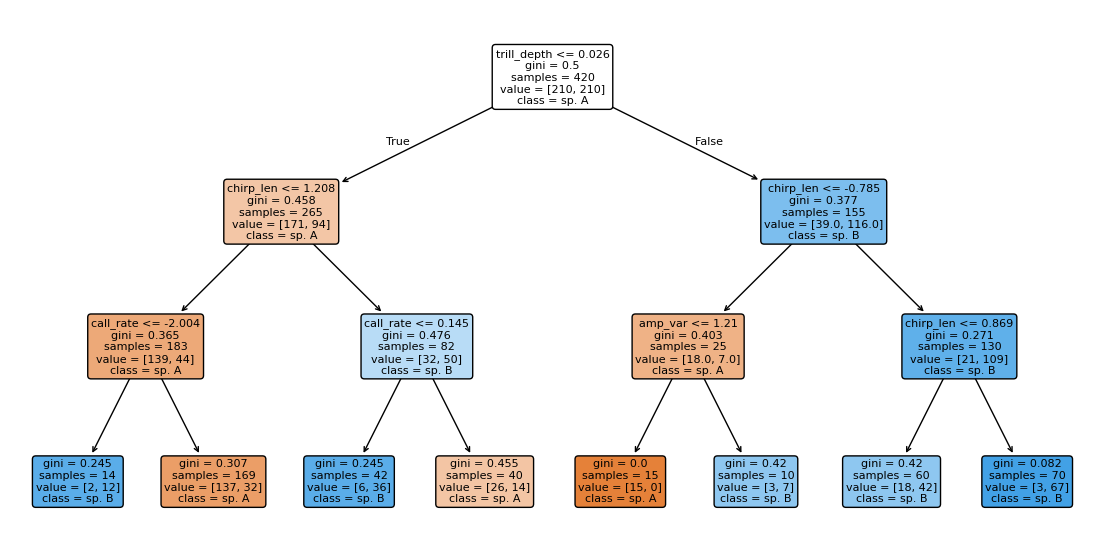

In [5]:
from sklearn.tree import plot_tree

small_tree = DecisionTreeClassifier(max_depth=3, random_state=11).fit(X_train, y_train)
fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(small_tree, feature_names=feature_names, class_names=["sp. A", "sp. B"],
          filled=True, rounded=True, fontsize=8, ax=ax)
plt.show()

Each node shows its split test, its Gini impurity, how many training samples reached it,
and their class split (`value`). Here the root splits on `trill_depth <= 0.03` -- the single
most discriminating question -- starting from a Gini of 0.500 over all 420 training calls.
Follow the yes/no branches and you can read the model's reasoning aloud -- the readability no
other model in this course offers.

## Step 3: Bag Them, Grow a Forest

Instead of pruning one tree, grow *many* on bootstrap resamples and let them vote.
`BaggingClassifier` does exactly that; `RandomForestClassifier` adds a random feature
subset at each split for extra diversity (and can score itself out-of-bag for free):

In [6]:
bag = BaggingClassifier(DecisionTreeClassifier(random_state=11), n_estimators=200,
                        n_jobs=-1, random_state=11).fit(X_train, y_train)
print(f"bagging (200 trees) test accuracy: {accuracy_score(y_test, bag.predict(X_test)):.3f}")

forest = RandomForestClassifier(n_estimators=200, oob_score=True,
                                random_state=11, n_jobs=-1).fit(X_train, y_train)
print(f"random forest (200) test accuracy: {accuracy_score(y_test, forest.predict(X_test)):.3f}")
print(f"random forest OOB score:           {forest.oob_score_:.3f}")

bagging (200 trees) test accuracy: 0.811


random forest (200) test accuracy: 0.817
random forest OOB score:           0.819


~~~text
bagging (200 trees) test accuracy: 0.811
random forest (200) test accuracy: 0.817
random forest OOB score:           0.819
~~~

The single tree managed 0.717; bagging jumps to **0.811** and the random forest to
**0.817** -- a ten-point lift from the very same trees, just averaged. The trees still
overfit their own bootstrap samples, but they overfit *differently*, so the vote cancels
the noise and keeps the signal: variance reduction in action. The **OOB score** (0.819)
is a validation estimate computed for free from the rows each tree never sampled.

## Step 4: Which Features Matter

Every split records how much it cut impurity, so the forest can rank the features by how
useful they were. Sort and print them:

In [7]:
order = forest.feature_importances_.argsort()[::-1]
for i in order:
    print(f"{feature_names[i]:12s} {forest.feature_importances_[i]:.3f}")

chirp_len    0.211
trill_depth  0.183
call_rate    0.170
call_pitch   0.119


amp_var      0.105
noise2       0.073


noise3       0.072
noise1       0.068


~~~text
chirp_len    0.211
trill_depth  0.183
call_rate    0.170
call_pitch   0.119
amp_var      0.105
noise2       0.073
noise3       0.072
noise1       0.068
~~~

The forest sorted signal from junk on its own: the five real acoustic features score
0.105 to 0.211, while the three noise columns sink to roughly 0.07 each. This is the same
job Lasso did in L10 by zeroing coefficients -- an *embedded* feature ranking, read
straight off the trained model.

## Your Turn

### Exercise 1 -- How many trees?

The forest's power is a large-numbers effect. Fit a `RandomForestClassifier` for
`n_estimators` in `(1, 5, 25, 100, 300)` and print the test accuracy of each. How few
trees does it take before the score stops climbing?

**Hint:** loop over the sizes, fit a forest each time with `random_state=11`, and print `accuracy_score` on the test set.

In [8]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
n_estimators=  1: test 0.644
n_estimators=  5: test 0.817
n_estimators= 25: test 0.817
n_estimators=100: test 0.817
n_estimators=300: test 0.822
~~~

A single tree in the forest scores just 0.644 -- worse than the standalone tree, because
it sees only a bootstrap sample and a feature subset. But five trees already reach 0.817,
and adding more barely moves the needle. The variance reduction kicks in fast; you rarely
need thousands of trees.
</details>

### Exercise 2 -- Does the split criterion matter?

scikit-learn defaults to Gini impurity, but entropy is an option. Fit a depth-3 tree with
`criterion="gini"` and again with `criterion="entropy"`, and compare their test accuracy.

**Hint:** loop over `("gini", "entropy")`, pass it as the `criterion` argument, keep `max_depth=3, random_state=11`.

In [9]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
criterion=gini     test 0.767
criterion=entropy  test 0.761
~~~

Almost no difference -- 0.767 versus 0.761. Gini and entropy usually pick very similar
splits, so the choice rarely matters in practice; Gini is the default mostly because it is
a touch cheaper to compute. Spend your tuning effort on `max_depth` and `n_estimators`, not
the criterion.
</details>

## Summary

- A single unpruned tree memorized the training set (accuracy 1.000) yet scored only
  0.717 on the test set -- the textbook high-variance overfitter from L09.
- `max_depth` is the flexibility dial: capping it lifted test accuracy to about 0.767, but
  one tree, however tuned, hit a ceiling.
- Bagging 200 trees (0.811) and a random forest (0.817, OOB 0.819) leapt past that ceiling
  by averaging many trees that overfit *differently* -- variance reduction by voting.
- The forest's feature importances ranked the five real features (0.105-0.211) above the
  three noise columns (~0.07), an embedded feature ranking like L10's Lasso.
- Next (L13): boosting -- instead of averaging independent trees, build them in sequence,
  each correcting the last, to attack bias rather than variance.